#Environment Setup

In [157]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [146]:
# Importing the nececassy libraries and frameworks
import pandas as pd
import numpy as np,random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

#Data loading

In [147]:
# Reading the file into a Pandas dataframe
df_raw = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

#Exploratory Data Analysis

In [ ]:
#Making a copy of the data for EDA
df=df_raw.copy()

## Basic Inspection

In [ ]:
df.shape

#Number of rows and columns
rows=df.shape[0]
cols= df.shape[1]
print(f"Dataset has {rows} rows and {cols} columns")

Dataset has 7043 rows and 21 columns


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
#Checking the datatypes
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Note: TotalCharges is an object dtype, SeniorCitizen is int64.

In [ ]:
#Checking empty strings in categorical columns
obj_cols= df.select_dtypes(include='object').columns
(df[obj_cols] == '').sum()

,0
customerID,0
gender,0
Partner,0
Dependents,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


* From the above explorations,'TotalCharges' was of data type,'object'. However logically since total charges should be a numeric column, the data type is converted to cotinue exploration.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# Descriptions for the numerical features
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# Descriptions for the categorical features
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [ ]:
# Check for missing values in the dataset
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



##Target feature analysis





In [ ]:
# Value distribution of traget variable
print(df['Churn'].value_counts(normalize=True))
df['Churn'].value_counts()

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


,count
Churn,
No,5174
Yes,1869


In [ ]:
sns.set_theme(style="whitegrid", palette="Set2")

Text(0.5, 1.0, 'Churn distribution')

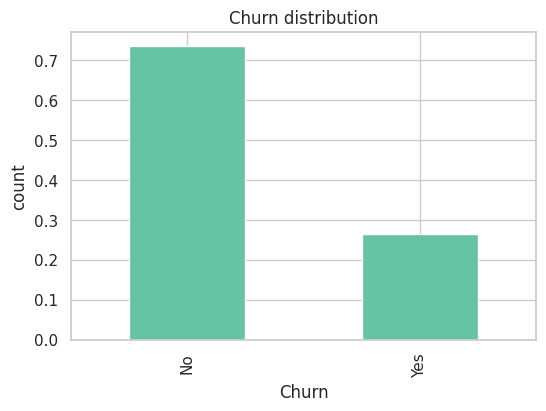

In [ ]:
#Plotting the target distriution
plt.figure(figsize=(6, 4))
ax = df['Churn'].value_counts(normalize=True).plot.bar()
ax.set_ylabel('count'); ax.set_title('Churn distribution')

* Target analysis shows clear class imbalanace of the traget. Therefore balancing strategies must be done to avoid bias in the modelling phase

## Univariate Analysis
To build a clear foundation of the dataset, each feature is independently analyzed.


In [ ]:
#Numerical column list
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_columns)
print(" ")

#categorical column list
non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()
non_numeric_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
 


['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

###Categorical features

In [ ]:
#Non numeric columns without the ID and Churn columns for plotting
non_numeric_columns.remove('customerID')
non_numeric_columns.remove('Churn')
non_numeric_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

Since the SeniorCitizen column was of numeric data type, it was mapped temporarily for plotting.

In [ ]:
df_plot = df.copy()
df_plot['SeniorCitizen'] = df_plot['SeniorCitizen'].map({0: "No", 1: "Yes"})

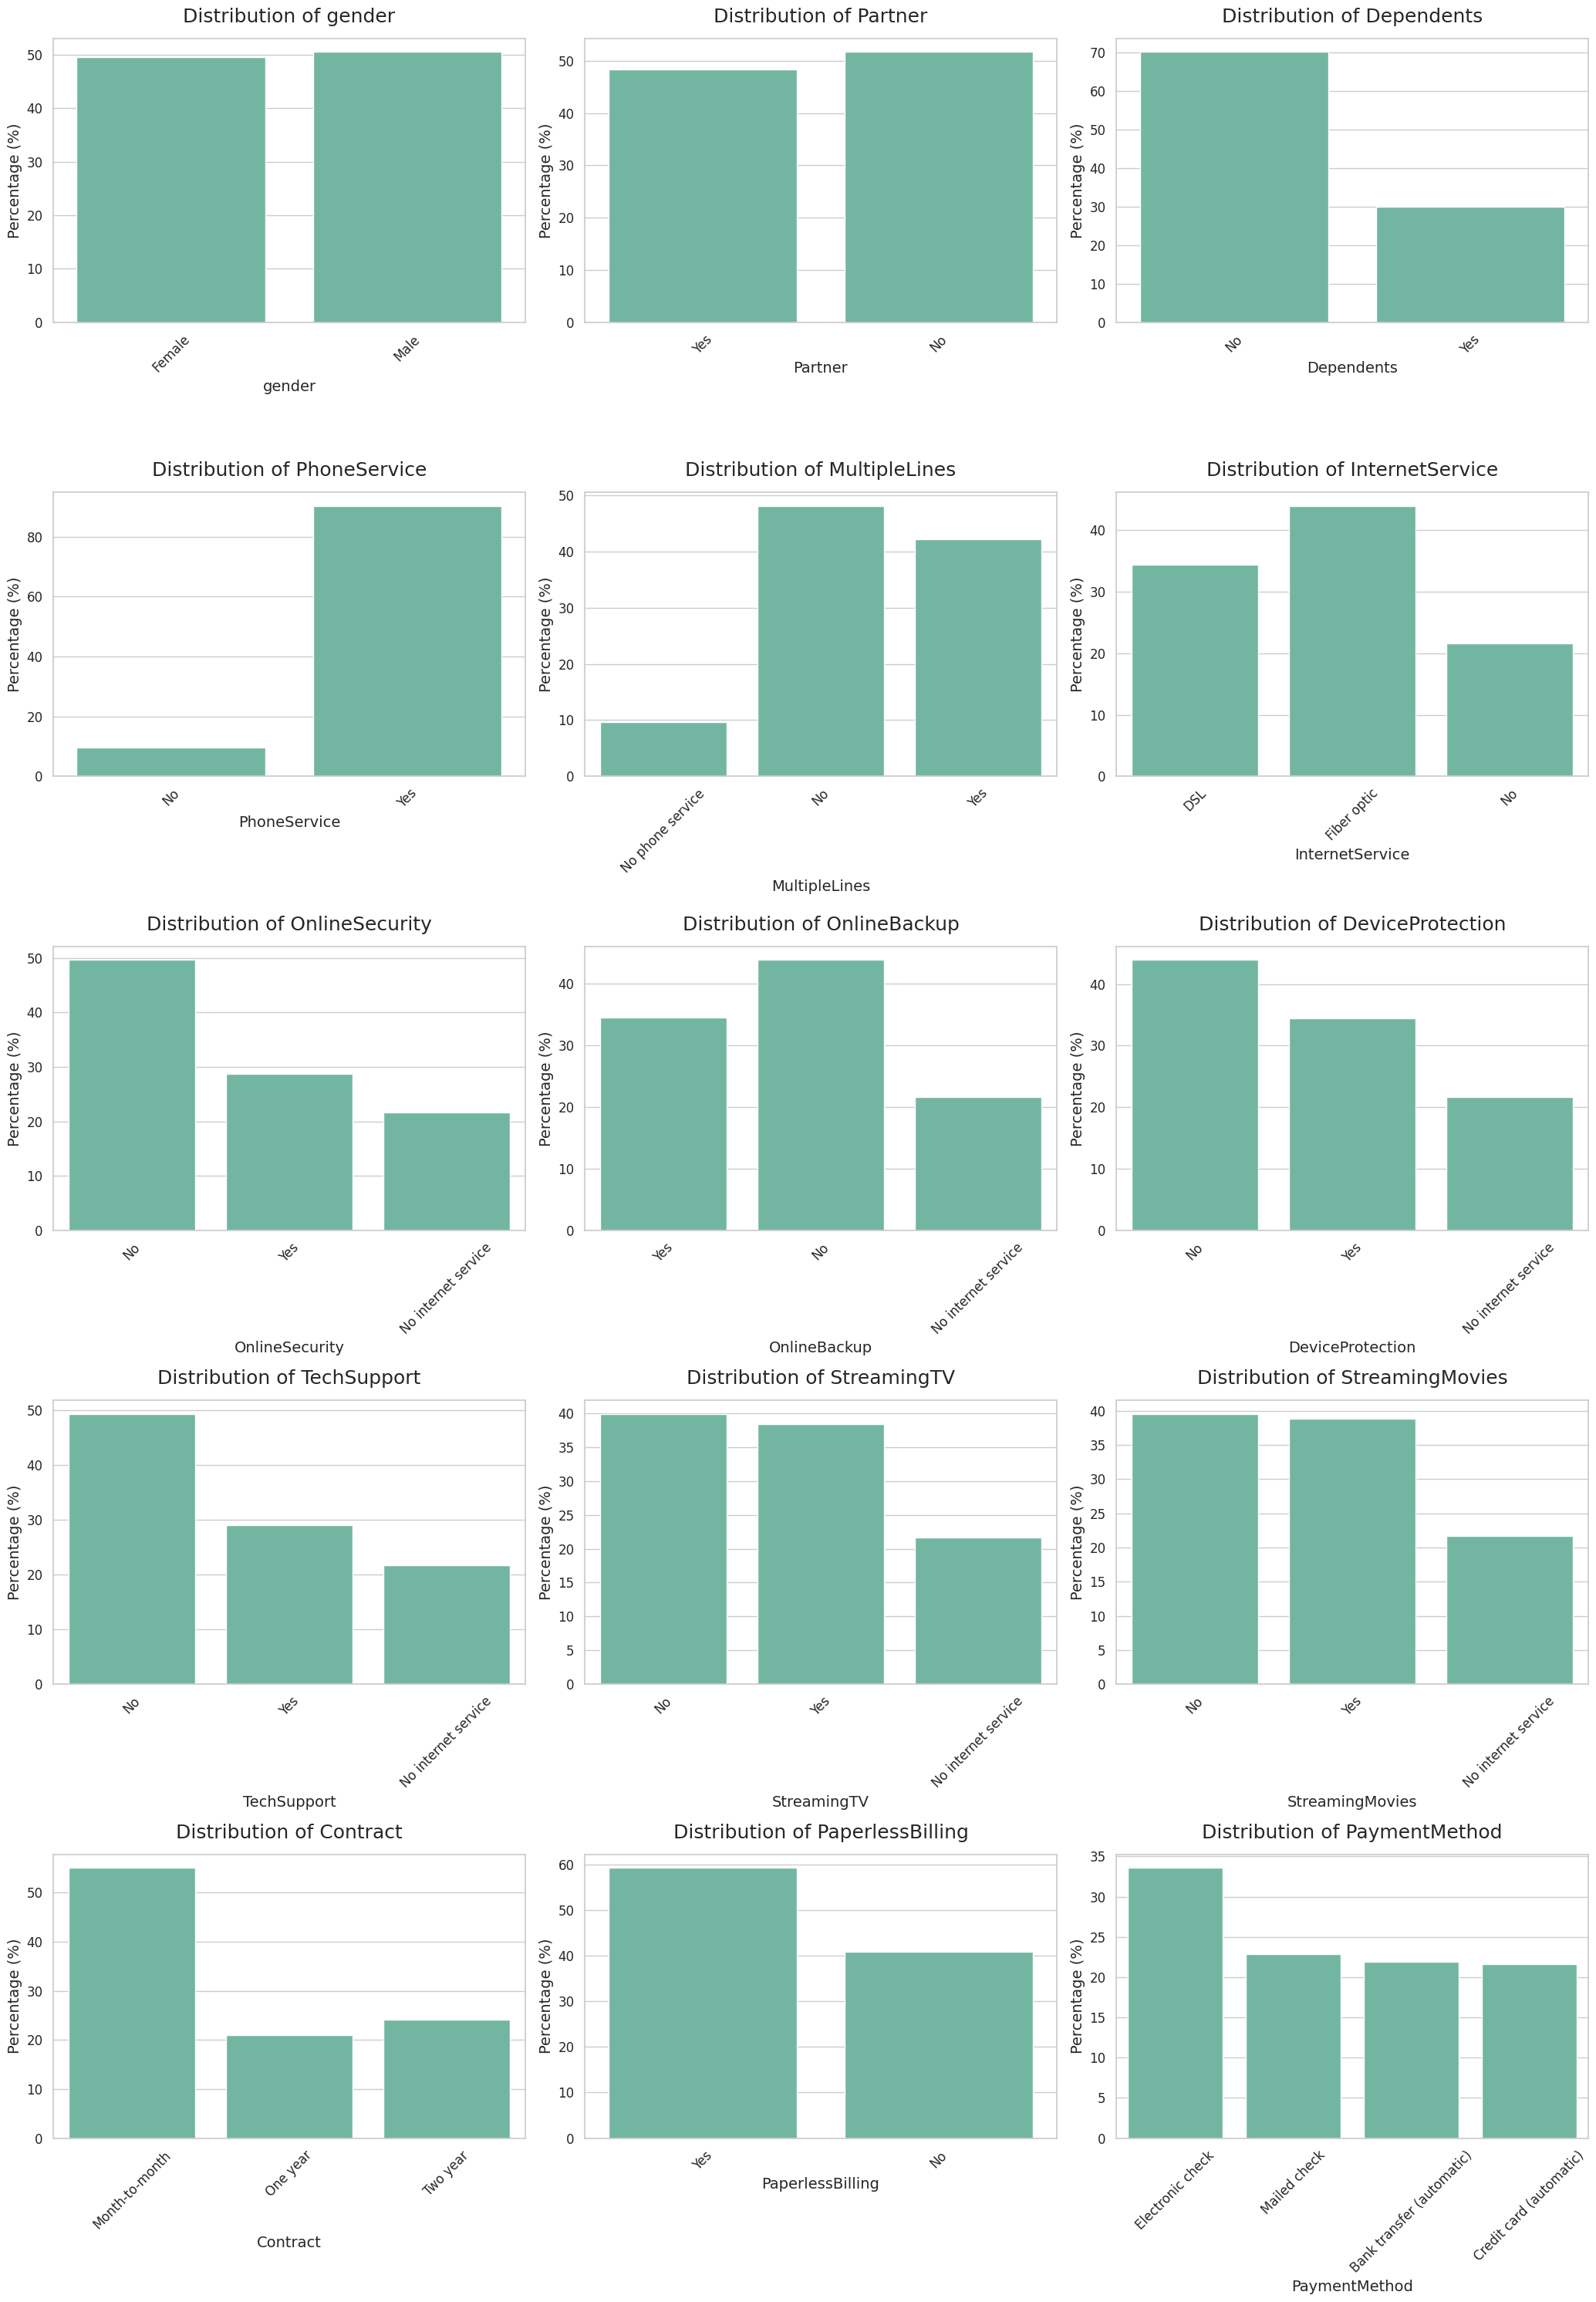

In [ ]:
#Plotting categorical columns except ID and target
cols_per_row = 3
num_plots = len(non_numeric_columns)
rows = (num_plots + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 7, rows * 6))
axes = axes.flatten()

# loop to acess each feature
for i, col in enumerate(non_numeric_columns):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        stat='percent'
    )

    # Titles & labels
    axes[i].set_title(f"Distribution of {col}", fontsize=18, pad=15)
    axes[i].set_xlabel(col, fontsize=14)
    axes[i].set_ylabel("Percentage (%)", fontsize=14)

    # Clearer ticks
    axes[i].tick_params(axis='x', rotation=45, labelsize=12)
    axes[i].tick_params(axis='y', labelsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

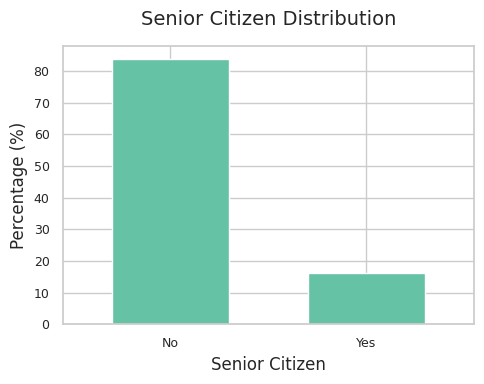

In [ ]:
# Converted categorical 'SeniorCitizen' plot.
senior_pct = df_plot['SeniorCitizen'].value_counts(normalize=True) * 100
plt.figure(figsize=(5,4))
ax = senior_pct.plot.bar(width=0.6)

# title and label styling
ax.set_title("Senior Citizen Distribution", fontsize=14, pad=15)
ax.set_xlabel("Senior Citizen", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)

# tick styling
ax.tick_params(axis='x', labelsize=9, rotation=0)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()


*Observations*


**Demographics**
- Gender distribution is almost perfectly balanced.  
- Senior citizens represent a very small minority of the customer base.  
- Most customers do not have partners or dependents.

**Phone & Internet Services**
- Phone service is nearly universal, with only a small minority not subscribed.  
- Most customers have one phone line, with a similar proportion having multiple lines.  
- Fiber optic is the most common internet service type, followed by DSL.  
- Around one‑fifth of customers have no internet service.

**Online Security & Support Services**
- Roughly half of customers do not have online security, device protection, or tech support.  
- About 30% subscribe to each of these services.  
- The remaining proportion corresponds to customers without internet service.

**Streaming Services**
- Among internet users, streaming TV and streaming movies have nearly identical adoption rates.    
- Customers without internet service are naturally excluded from these categories.

**Contracts & Billing**
- Monthly contracts are the dominant contract type.  
- More than half of customers use paperless billing.  
- Electronic check is the most common payment method, with the remaining methods evenly distributed.

### Numerical features

Logical numerical features include tenure, MonthlyCharges and TotalCharges.

*   Tenure : How many months the customer has stayed with the company







**Histograms + Kernel Density Estimate (KDE) plots**


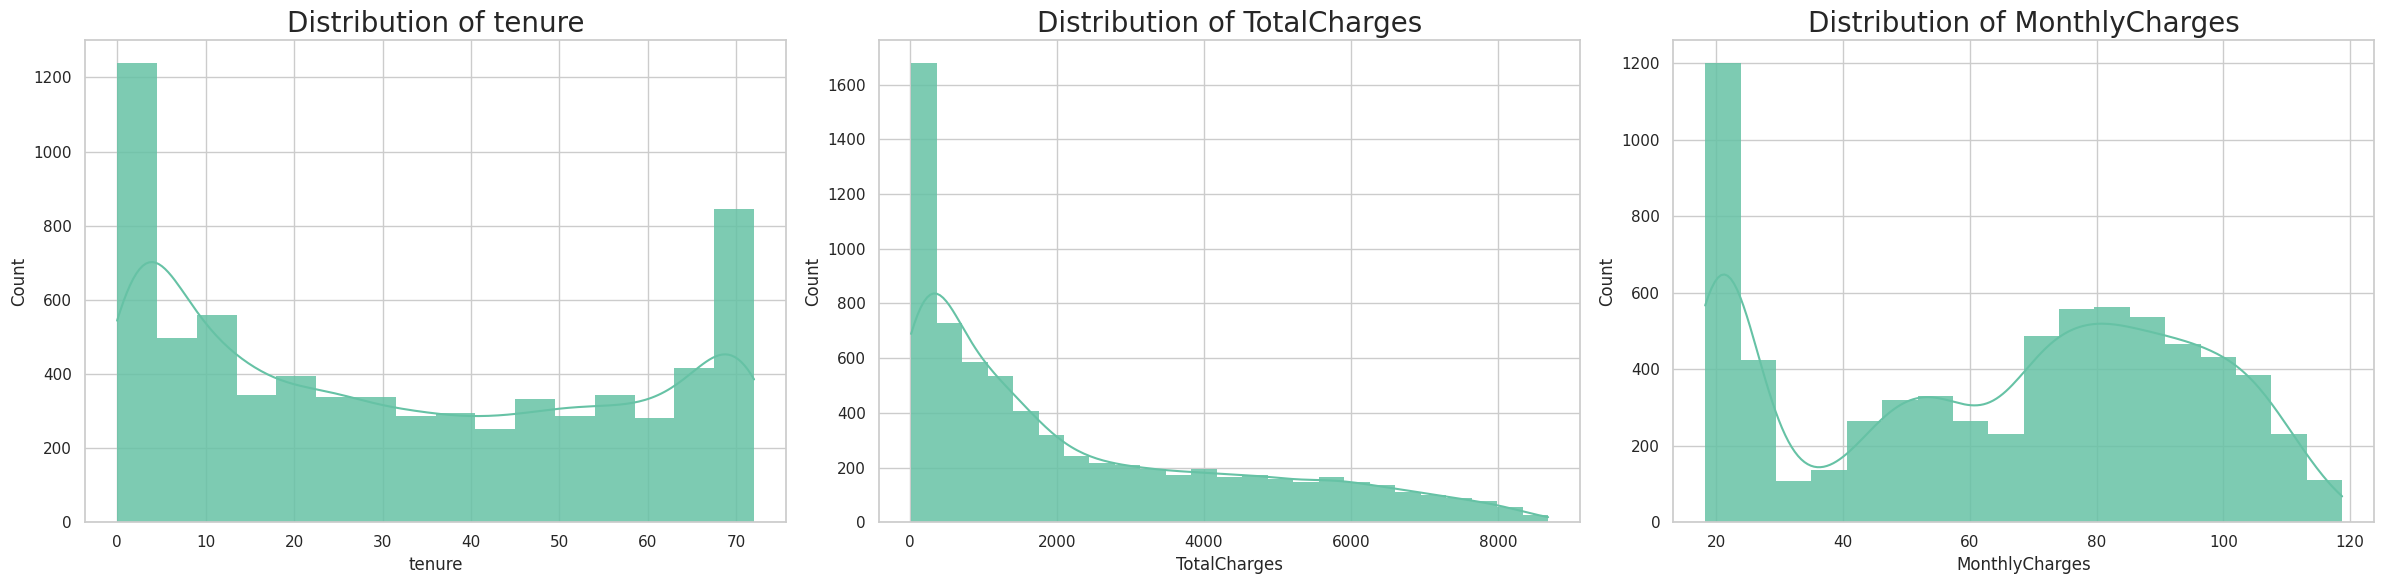

In [ ]:
#Plotting the numerical columns using KDE's
numeric_cols = ['tenure', 'TotalCharges', 'MonthlyCharges']
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(
        data=df, x=col, kde=True, ax=ax,
        edgecolor="none", alpha=0.85
    )
    ax.set_title(f"Distribution of {col}", fontsize=20)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


*Observations*

**Tenure**
  *   Right skewed
  *   Most people are new customers
  *   Rise between 60- 70 months

**TotalCharges**
  *   Right skewed
  *   Majority pays less that 2,000
  *   Has a moderate spread

**MonthylCharges**
  *   Marginally right skewed
  *   Has a large spread, possible outliers
  






###Outlier Inspection

**Inter quartile range (IQR) method**

In [ ]:
#IQR method for outlier identification
def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.50 * IQR
    upper = Q3 + 1.50 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

for col in ['MonthlyCharges','TotalCharges','tenure']:
    print(f'{col} = {find_outliers(col)}')

MonthlyCharges = 0
TotalCharges = 0
tenure = 0



**Boxplots of numerical features**

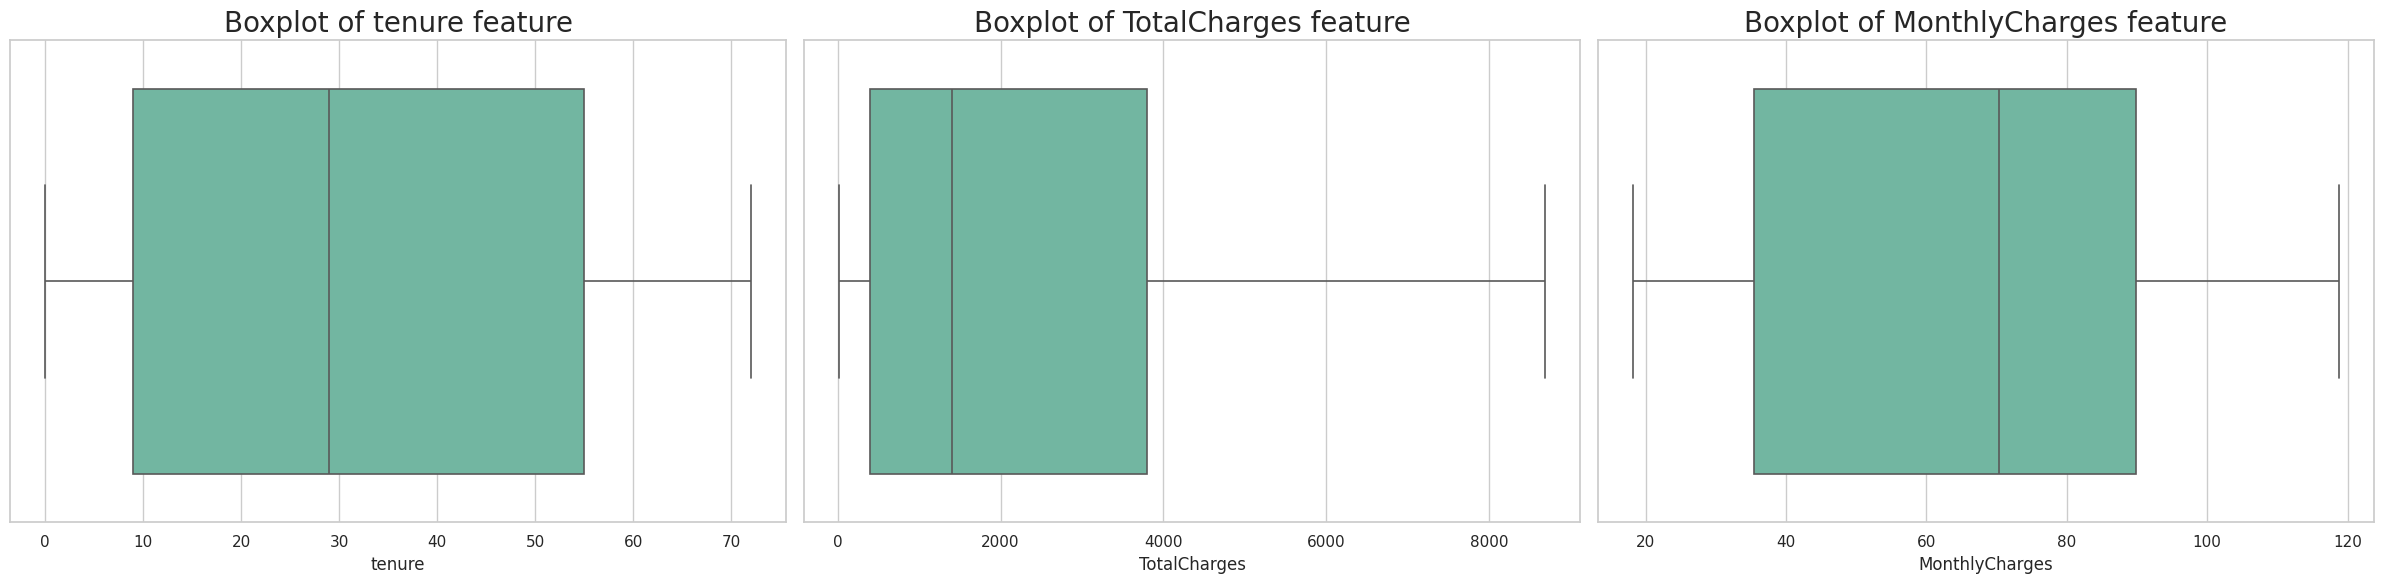

In [ ]:
#Plotting the numerical columns using boxplots
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        data=df, x=col, ax=ax,
        linewidth=1.2
    )
    ax.set_title(f"Boxplot of {col} feature", fontsize=20)
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()


* IQR method (implemented with the find_outliers()) + box plots both showed that no potential outliers in all numerical features.

## Bivariate Analysis
To understand how each feature relates to churn, bivariate relationships with the target variable is done for each feature. 100% stacked bar charts are utilized.


###Categorical features by Churn Rate

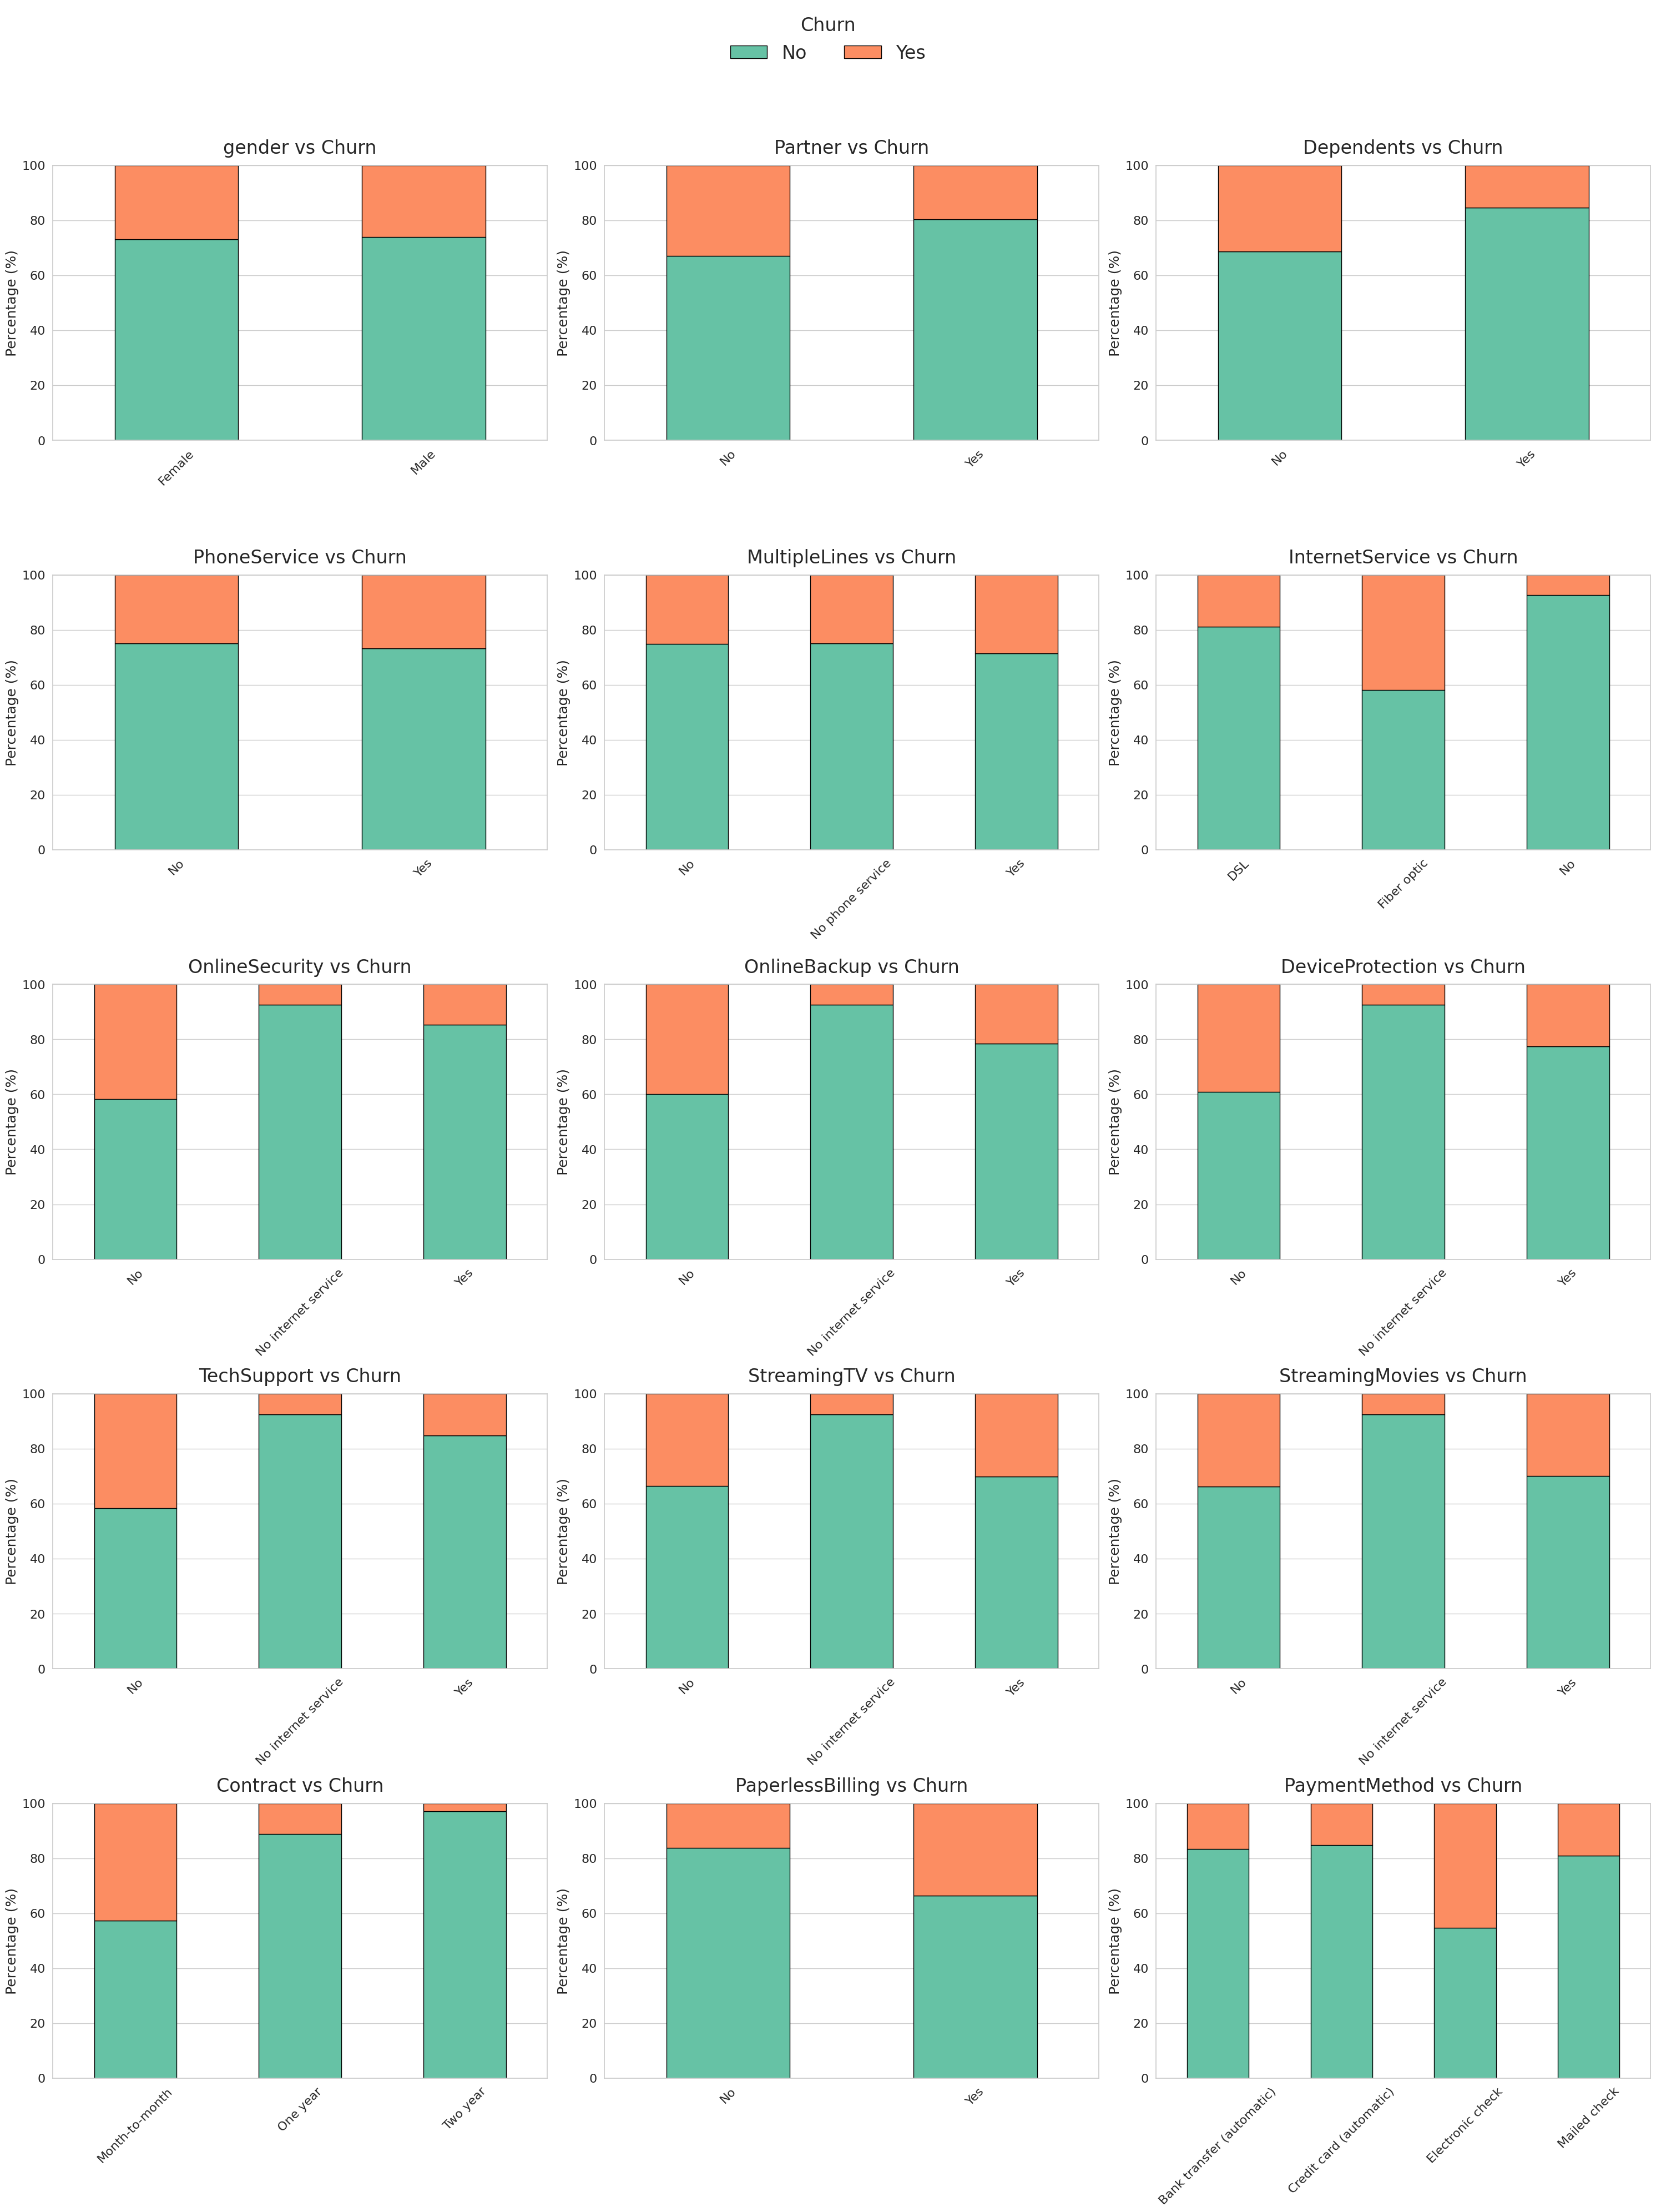

In [ ]:
import math
cat_features = [
    'gender','Partner','Dependents','PhoneService','MultipleLines',
    'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies','Contract',
    'PaperlessBilling','PaymentMethod'
]

per_plot_w, per_plot_h = 10, 8
n = len(cat_features)
cols = 3
rows = math.ceil(n / cols)
figsize = (per_plot_w * cols, per_plot_h * rows)

fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
axes = axes.flatten()

colors = sns.color_palette("Set2", 2)

for ax, feat in zip(axes, cat_features):
    ct = pd.crosstab(df[feat], df['Churn'], normalize='index') * 100

    ct.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors,
        edgecolor='black'
    )


    ax.set_title(f"{feat} vs Churn", fontsize=24, pad=15)
    ax.set_ylabel("Percentage (%)", fontsize=18)
    ax.set_xlabel("", fontsize=18)
    ax.set_ylim(0, 100)


    ax.tick_params(axis='x', labelsize=16, rotation=45)
    ax.tick_params(axis='y', labelsize=16)


    ax.legend_.remove()

for i in range(n, len(axes)):
    fig.delaxes(axes[i])

# Clean global legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    frameon=False,
    fontsize=24,
    title="Churn",
    title_fontsize=24
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

<Figure size 400x300 with 0 Axes>

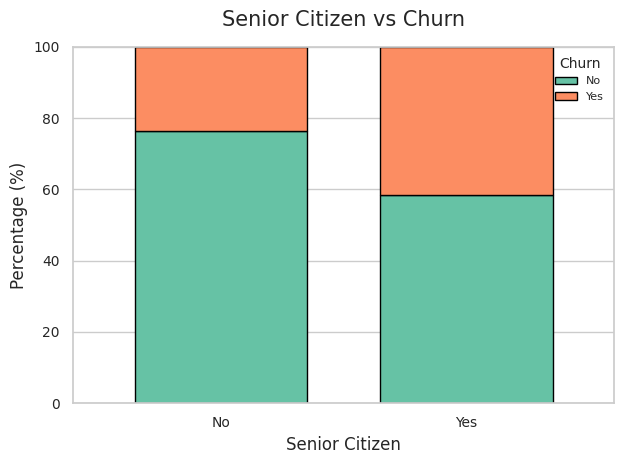

In [ ]:
senior_pct = (
    df_plot.groupby('SeniorCitizen')['Churn']
           .value_counts(normalize=True)
           .unstack() * 100
)

senior_pct = senior_pct.rename(columns={0: "No Churn", 1: "Churn"})
colors = sns.color_palette("Set2", 2)
plt.figure(figsize=(4, 3))
ax = senior_pct.plot(
    kind='bar',
    stacked=True,
    color=colors,
    edgecolor='black',
    width=0.7
)
ax.set_title("Senior Citizen vs Churn", fontsize=15, pad=15)
ax.set_xlabel("Senior Citizen", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', labelsize=10, rotation=0)
ax.tick_params(axis='y', labelsize=10)

plt.legend(
    title="Churn",
    title_fontsize=10,
    fontsize=8,
    loc='upper right',
    frameon=False
)

plt.tight_layout()
plt.show()




###Numerical features by Churn Rate

**Churn Rate by tenure groups**

/tmp/ipython-input-1103963139.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(tenure_bin)['Churn']


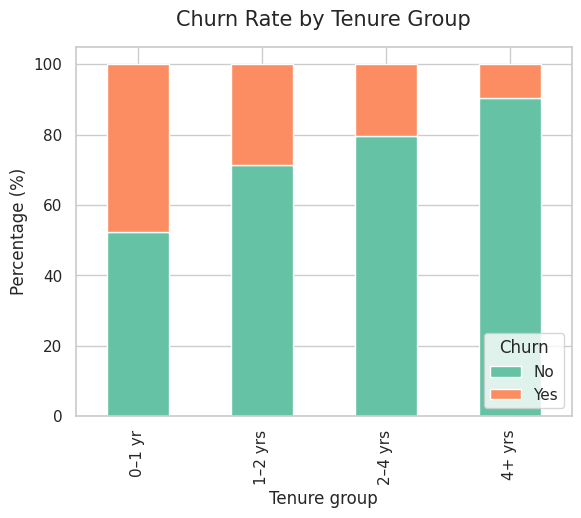

In [ ]:
#Binning tenure
tenure_bin = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–1 yr', '1–2 yrs', '2–4 yrs', '4+ yrs']
)

tenure_pct = (
    df.groupby(tenure_bin)['Churn']
      .value_counts(normalize=True)
      .unstack() * 100
)

tenure_pct.plot(kind='bar', stacked=True)
plt.ylabel('Percentage (%)')
plt.xlabel('Tenure group')
plt.title('Churn Rate by Tenure Group', fontsize=15, pad=15)
plt.legend(title='Churn',loc='lower right')


**Churn rate by  monthly charges groups**

/tmp/ipython-input-1572121395.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(monthly_bin)['Churn']


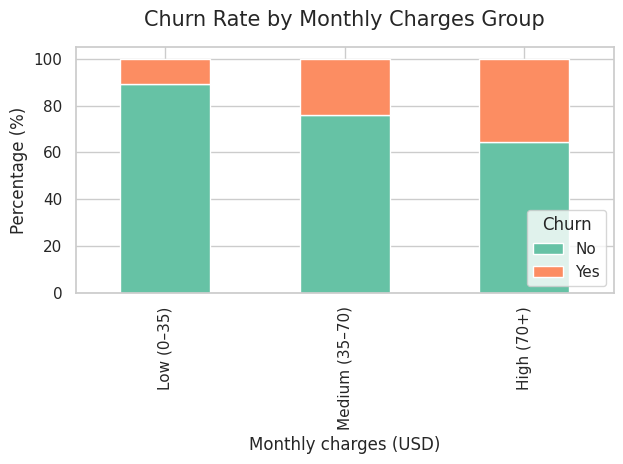

In [ ]:
#monthly charge bins
monthly_bin = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, df['MonthlyCharges'].max()],
    labels=['Low (0–35)', 'Medium (35–70)', 'High (70+)']
)

monthly_pct = (
    df.groupby(monthly_bin)['Churn']
      .value_counts(normalize=True)
      .unstack() * 100
)


monthly_pct.plot(kind='bar', stacked=True)
plt.ylabel('Percentage (%)')
plt.xlabel('Monthly charges (USD)')
plt.title('Churn Rate by Monthly Charges Group', fontsize=15, pad=15)
plt.legend(title='Churn', loc='lower right')
plt.tight_layout()
plt.show()


**Churn rate by total charges groups**

/tmp/ipython-input-587539195.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(total_bin)['Churn']


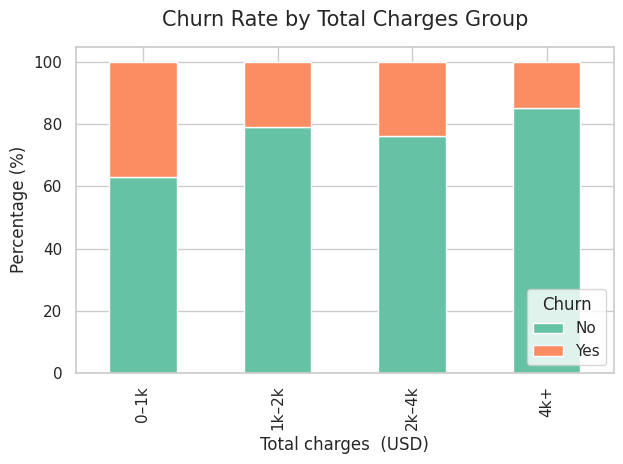

In [ ]:
# ---- TotalCharges Binned Stacked Bar Chart ----

# First ensure TotalCharges is numeric (Telco dataset often has whitespace problems)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

total_bin = pd.cut(
    df['TotalCharges'],
    bins=[0, 1000, 2000, 4000, df['TotalCharges'].max()],
    labels=['0–1k', '1k–2k', '2k–4k', '4k+']
)

total_pct = (
    df.groupby(total_bin)['Churn']
      .value_counts(normalize=True)
      .unstack() * 100
)

total_pct.plot(kind='bar', stacked=True)
plt.ylabel('Percentage (%)')
plt.xlabel('Total charges  (USD)')
plt.title('Churn Rate by Total Charges Group', fontsize=15, pad=15)
plt.legend(title='Churn', loc='lower right')
plt.tight_layout()
plt.show()


##Correlation Matrix and Feature Cross Check


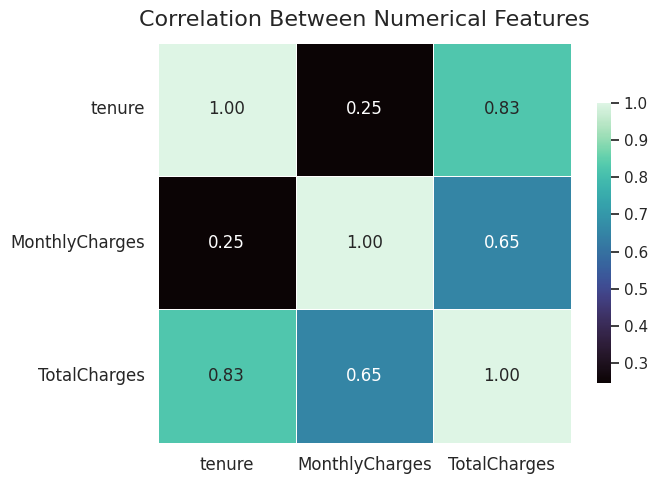

In [ ]:
#numerical features
numerical = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Computing the correlation matrix
corr = df[numerical].corr()

plt.figure(figsize=(7, 5))
ax = sns.heatmap(
    corr,

    annot=True,
    fmt=".2f",
    cmap="mako",
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}
)

ax.set_title("Correlation Between Numerical Features", fontsize=16, pad=12)
ax.tick_params(axis='x', labelsize=12, rotation=0)
ax.tick_params(axis='y', labelsize=12, rotation=0)

plt.tight_layout()
plt.show()

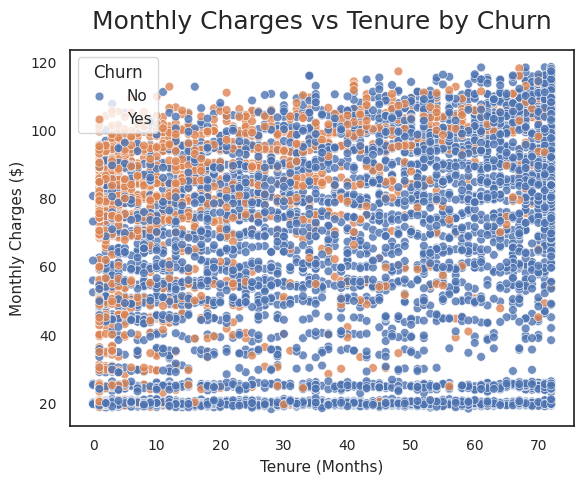

In [ ]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    s=40,
    alpha=0.8
)

plt.title("Monthly Charges vs Tenure by Churn", fontsize=18, pad=15)
plt.xlabel("Tenure (Months)", fontsize=11)
plt.ylabel("Monthly Charges ($)", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

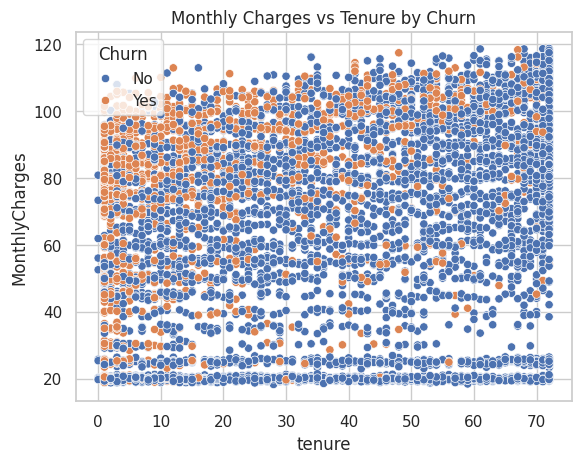

In [ ]:
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn')
plt.title("Monthly Charges vs Tenure by Churn")
plt.show()


# Data Preprocessing

In [ ]:
# Dataframe copy which will be used for modelling as well.
df_prep=df_raw.copy()

###**Set Global seeds**

In [ ]:
#setting global seeds for easy access
SEED= 42

#for numpy
np.random.seed(SEED)

#for Python
random.seed(SEED)

#for tensorflow
tf.random.set_seed(SEED)



##**Data type conversions**

The following changes were made to feature data types to better represent real-world scenario.
  * TotalCharges [ from object -> numeric]
  * SeniorCitizen [from int -> category]

In [ ]:
# Convert the totalCharges column to numeric and morphing it to the dataset
# Coerced to replace invalid values with NaN
df_prep['TotalCharges'] = pd.to_numeric(df_prep['TotalCharges'], errors='coerce')

In [ ]:
#converting the dtype of senior_citizen to object
df_prep['SeniorCitizen'] = df_prep['SeniorCitizen'].astype('category')
df_prep['SeniorCitizen'].dtypes

CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64)

In [ ]:
df_prep.dtypes

,0
customerID,object
gender,object
SeniorCitizen,category
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


##**Handle missing values**

In [ ]:
# Checking the percentage of the missing records
percent=(df_prep.isna().sum())
percent

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df_prep.isna().sum() #11 NaN values after type conversion

#Remove the 11 rows from the data set since <1% and the effect is negligible.
df_prep=df_prep.dropna(subset=['TotalCharges'])

#remove confirmation
df_prep.isna().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##**Handle outliers**
* IQR method will be used.

In [ ]:
def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

# Call it with column names
for col in ['MonthlyCharges','tenure','TotalCharges']:
  print(f'{col} = {find_outliers(col)}')

MonthlyCharges = 0
tenure = 0
TotalCharges = 0


Since there are no outliers visible, preprocessing was continued without any changes made for outliers.

##**Check for duplicates**

In [ ]:
# Checking for duplicates
df_prep.duplicated().sum()

np.int64(0)

The above test proved there are no duplicates in the dataset therefore no steps to manipulate the data was taken and preprocessing is continued.

##**Drop irrelavant columns**

Since the customerID is irrelavant for the modelling phase, the decision was taken to drop the column from the dataset.

In [ ]:
#Dropping the customer ID column
df_prep=df_prep.drop(columns=['customerID'])

#confirmation for column drop
df_prep.shape #nee df has 20 columns instead of the 21 original columns

(7032, 20)

##**Tranform the column names**
Since the dataset's column names follow multiple cases of snake case and camel case and pascal case, the columns were transformed to have snake case to follow naming conventions better.

In [ ]:
#Renaming all the columns to have snake case
df_prep.columns

df_prep=df_prep.rename(columns={'gender':"gender",
                   'SeniorCitizen':"senior_citizen",
                   'Partner':"partner",
                   'Dependents':"dependants",
                   'tenure':"tenure",
                  'PhoneService':"phone_service",
                   'MultipleLines':"multiple_lines",
                   'InternetService':"internet_service",
                   'OnlineSecurity':"online_security",
                  'OnlineBackup':"online_backup",
                   'DeviceProtection':"device_protection",
                   'TechSupport':"tech_support",
                   'StreamingTV':"streaming_tv",
                  'StreamingMovies':"streaming_movies",
                   'Contract':"contract",
                   'PaperlessBilling':"paperless_billing",
                   'PaymentMethod':"payment_method",
                  'MonthlyCharges':"monthly_charges",
                   'TotalCharges':"total_charges",
                   'Churn':"churn"
                   }
          , errors="raise")

df_prep

,gender,senior_citizen,partner,dependants,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


##**Encoding and Scaling.**

For encoding the categorical features, one hot encoding for all columns are used since the column count is not large.

For scaling, min max normalization (using MinMaxScaler) is used for the numerical cloumns since all the columns are of positive values, roughly bounded and contains no outliers.

The target variable was separated from the feature set prior to encoding to prevent data leakage. Since the target is binary, it was mapped directly rather than one-hot encoding, which would be unnecessary for a two-class outcome.


**Split features and target**

In [ ]:
#Splitting the features and columns
X= df_prep.drop('churn', axis=1)
y=df_prep['churn'].map({'No':0, 'Yes':1})


**Scaling and encoding pipeline**

In [ ]:
#Access the categorical and numerical cloumns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


In [ ]:
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer

#Encoding categorical columns -> one-hot encoding
# Scaling numeric columns -> min max normalization (with MinMaxScaler)

#Preprocessor for the flow
preprocessor= ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat_cols),
        ('num', MinMaxScaler(),num_cols)
    ]
)

X_encoded=preprocessor.fit_transform(X)

# Change for readability
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=preprocessor.get_feature_names_out(),
    index=X.index
)

##**Split data (train and test set)**
Stratified splitting was used to preserve the class proportions of the target variable in both the training and test sets.


In [ ]:
from sklearn.model_selection import train_test_split

#Train test split using the standard ratio
X_train, X_test, y_train, y_test= train_test_split(
    X_encoded_df,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)


# Model Development

In [ ]:
# Imports for the modelling
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
from sklearn.metrics import make_scorer, f1_score
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
import joblib


Cross validation & Class Weight Configuration


In [158]:
#Scoring metrics
scoring={
    'f1':'f1',
    'roc_auc':'roc_auc',
    'avg_precision':'average_precision'
}

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {c: w for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.6809927360774818), np.int64(1): np.float64(1.8812709030100334)}


## Iterative Experimentation: Decision Tree

Baseline model (with default parameters)

In [ ]:
# Bulding the base model
from sklearn.metrics import classification_report, roc_auc_score
base_model = DecisionTreeClassifier(random_state=SEED)
base_model.fit(X_train,y_train)

y_pred=base_model.predict(X_test)
y_prob=base_model.predict_proba(X_test)[:,1]
y_pred_train = base_model.predict(X_train)
y_pred_test = base_model.predict(X_test)


print("Base decision tree results.")
print(classification_report(y_test,y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))
prec, rec, _ = precision_recall_curve(y_test, y_prob)
print("\nPR AUC:", auc(rec, prec))
print("TRAIN REPORT:")
print(classification_report(y_train, y_pred_train))
print("TRAIN ROC AUC:", roc_auc_score(y_train, base_model.predict_proba(X_train)[:, 1]))
print("TEST ROC AUC:", roc_auc_score(y_test,base_model.predict_proba(X_test)[:, 1]))


Base decision tree results.
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1033
           1       0.49      0.50      0.49       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407


Confusion matrix:
 [[837 196]
 [188 186]]

ROC AUC: 0.6540345082854051

PR AUC: 0.5592451989357666
TRAIN REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4130
           1       1.00      1.00      1.00      1495

    accuracy                           1.00      5625
   macro avg       1.00      1.00      1.00      5625
weighted avg       1.00      1.00      1.00      5625

TRAIN ROC AUC: 0.999995141188951
TEST ROC AUC: 0.6540345082854051


The baseline has 2 main probelms
  - Overfitting
  - Target class imbalance

Therefore both these problems must be approached separately.

First, restricting the tree to reduce the wild overfitting

- Since it has memorized the dataset and has grown uncontrolled, a few default parameters are passed to control the depth, growth and splits.

In [ ]:
restricted_tree = DecisionTreeClassifier(
    max_depth=5,               # shallow enough to prevent memorization
    min_samples_split=20,      # to avoid tiny splits
    min_samples_leaf=10,       # to avoid tiny leaves
    random_state=SEED
)

restricted_tree.fit(X_train, y_train)
y_pred = restricted_tree.predict(X_test)
y_proba = restricted_tree.predict_proba(X_test)[:, 1]
y_pred_train = restricted_tree.predict(X_train)
y_pred_test = restricted_tree.predict(X_test)

print("Restricted Tree – Classification Report\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_proba))
print("TRAIN REPORT:")
print(classification_report(y_train, y_pred_train))
print("TRAIN ROC AUC:", roc_auc_score(y_train, restricted_tree.predict_proba(X_train)[:, 1]))
print("TEST ROC AUC:", roc_auc_score(y_test,restricted_tree.predict_proba(X_test)[:, 1]))



Restricted Tree – Classification Report

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1033
           1       0.60      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407

Confusion Matrix:
[[882 151]
 [144 230]]

ROC AUC: 0.8283269745458688
TRAIN REPORT:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4130
           1       0.62      0.63      0.62      1495

    accuracy                           0.80      5625
   macro avg       0.74      0.74      0.74      5625
weighted avg       0.80      0.80      0.80      5625

TRAIN ROC AUC: 0.8535660433891826
TEST ROC AUC: 0.8283269745458688


Now since the tree is restricted and the overfitting is controlled, the next challenge of class imbalance will be adressed. To balance the classes, 3 approches were tested on the restricted tree in the following order.

1. Class_weight=balanced parameter
2. Minority class over sampled with Synthetic Minority Over-sampling Technique (SMOTE)
3. Minority class over sampled with RandomOverSampler.

1.Restricted Decision tree with balanced class weights

In [ ]:
# Restricted tree with balanced class_weight='balanced'
balanced_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=None,
    class_weight='balanced',
    random_state=SEED
)

# Train
balanced_tree.fit(X_train, y_train)

# Predict
y_pred_bal = balanced_tree.predict(X_test)
y_proba_bal = balanced_tree.predict_proba(X_test)[:, 1]

y_pred_train = balanced_tree.predict(X_train)
y_pred_test = balanced_tree.predict(X_test)

# Evaluate the model
print("Balanced Restricted Tree – Classification Report\n")
print(classification_report(y_test, y_pred_bal))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bal))
print("\nROC AUC:", roc_auc_score(y_test, y_proba_bal))
print("TRAIN REPORT (balanced):")
print(classification_report(y_train, y_pred_train))
print("TRAIN ROC AUC:", roc_auc_score(y_train, balanced_tree.predict_proba(X_train)[:, 1]))
print("TEST ROC AUC:", roc_auc_score(y_test,balanced_tree.predict_proba(X_test)[:, 1]))



Balanced Restricted Tree – Classification Report

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

Confusion Matrix:
[[735 298]
 [ 77 297]]

ROC AUC: 0.8275789326555228
TRAIN REPORT (balanced):
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      4130
           1       0.53      0.83      0.64      1495

    accuracy                           0.76      5625
   macro avg       0.72      0.78      0.73      5625
weighted avg       0.82      0.76      0.77      5625

TRAIN ROC AUC: 0.8545165078105388
TEST ROC AUC: 0.8275789326555228


2. Restricted Decision tree with oversmapling through SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED)

# Apply SMOTE to training data
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Checking the new class distribution
print("Class distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())

#Train the algo
dt_smote = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=None,
    random_state=SEED
)


dt_smote.fit(X_train_sm, y_train_sm)

#Predict and evaluate
y_pred_sm = dt_smote.predict(X_test)
y_proba_sm = dt_smote.predict_proba(X_test)[:, 1]


y_pred_train = dt_smote.predict(X_train)
y_pred_test = dt_smote.predict(X_test)


print("SMOTE DT – Classification Report\n")
print(classification_report(y_test, y_pred_sm))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_sm))
print("\nROC AUC:", roc_auc_score(y_test, y_proba_sm))
print("TRAIN REPORT(smote):")
print(classification_report(y_train, y_pred_train))
print("TRAIN ROC AUC:", roc_auc_score(y_train, dt_smote.predict_proba(X_train)[:, 1]))
print("TEST ROC AUC:", roc_auc_score(y_test,dt_smote.predict_proba(X_test)[:, 1]))



Class distribution after SMOTE:
churn
0    4130
1    4130
Name: count, dtype: int64
SMOTE DT – Classification Report

              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1033
           1       0.52      0.71      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407

Confusion Matrix:
[[784 249]
 [109 265]]

ROC AUC: 0.81032996671343
TRAIN REPORT(smote):
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      4130
           1       0.55      0.73      0.63      1495

    accuracy                           0.77      5625
   macro avg       0.72      0.76      0.73      5625
weighted avg       0.80      0.77      0.78      5625

TRAIN ROC AUC: 0.836600127948691
TEST ROC AUC: 0.81032996671343


3. Restricted Decision Tree with oversaampling through RandomOverSampler

In [ ]:
#Random oversampling
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=SEED)

# Apply oversampling to training data
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# Check new class distribution
print("Class distribution after Random Oversampling:")
print(pd.Series(y_train_ros).value_counts())

#Train the tree
dt_ros = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=None,
    random_state=SEED
)

dt_ros.fit(X_train_ros, y_train_ros)

#predict and eval
y_pred_ros = dt_ros.predict(X_test)
y_proba_ros = dt_ros.predict_proba(X_test)[:, 1]


y_pred_train = dt_ros.predict(X_train)
y_pred_test = dt_ros.predict(X_test)

print("Random Oversampling DT – Classification Report\n")
print(classification_report(y_test, y_pred_ros))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ros))
print("\nROC AUC:", roc_auc_score(y_test, y_proba_ros))
print("TRAIN REPORT(ros):")
print(classification_report(y_train, y_pred_train))
print("TRAIN ROC AUC:", roc_auc_score(y_train, dt_ros.predict_proba(X_train)[:, 1]))
print("TEST ROC AUC:", roc_auc_score(y_test,dt_ros.predict_proba(X_test)[:, 1]))



Class distribution after Random Oversampling:
churn
0    4130
1    4130
Name: count, dtype: int64
Random Oversampling DT – Classification Report

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

Confusion Matrix:
[[753 280]
 [ 78 296]]

ROC AUC: 0.8327375744806412
TRAIN REPORT(ros):
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      4130
           1       0.53      0.80      0.64      1495

    accuracy                           0.76      5625
   macro avg       0.72      0.77      0.73      5625
weighted avg       0.81      0.76      0.77      5625

TRAIN ROC AUC: 0.8530780567995011
TEST ROC AUC: 0.8327375744806412


From the above results, the best performing tree is the restricted tree with random oversampling. (even though the balanced class weighted model comes close).

Therefore the randomly oversampled model will be chosen for hyperparameter tuning.

### Decision tree hyperparameter tuning

A two- stage tuning process was applied: RandomizedSearchCV was used to explore a broad parameter space, followed by GridSearchCV on the most promising ranges to obtain the final optimized hyperparameters.


In [ ]:
# Pipeline with randomizedSearchCV with the oversampled data.
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer
from scipy.stats import randint

SEED = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f1_scorer = make_scorer(f1_score, pos_label=1)

pipeline = Pipeline([
    ('oversample', RandomOverSampler(random_state=SEED)),
    ('model', DecisionTreeClassifier(random_state=SEED))
])

param_dist = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': randint(5, 18),
    'model__min_samples_split': randint(20, 120),
    'model__min_samples_leaf': randint(10, 80),
    'model__max_features': [None, 'sqrt', 'log2'],
}

rand_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring={'f1': f1_scorer, 'roc_auc': 'roc_auc'},
    refit='f1',
    cv=CV,
    n_jobs=-1,
    verbose=2,
    random_state=SEED,
    return_train_score=True
)

rand_search.fit(X_train, y_train)

print("Best Params:", rand_search.best_params_)
print("Best CV F1:", rand_search.best_score_)

best_dt = rand_search.best_estimator_
pred_train = best_dt.predict(X_train)
pred_test = best_dt.predict(X_test)

print("Train F1:", f1_score(y_train, pred_train))
print("Test F1:", f1_score(y_test, pred_test))



Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params: {'model__criterion': 'entropy', 'model__max_depth': 11, 'model__max_features': None, 'model__min_samples_leaf': 71, 'model__min_samples_split': 59}
Best CV F1: 0.6253314589192873
Train F1: 0.652796541475277
Test F1: 0.6193548387096774


Based on the narrowed parameter ranges from the randomized search, the tuning was refined using GridSearchCV to obtain the fully optimized final model.

##Optimised Decision Tree (Selected Model)

In [ ]:
# Imports
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer
from scipy.stats import randint
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import classification_report, roc_auc_score


# Stratified CV + F1 scorer
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f1_scorer = make_scorer(f1_score, pos_label=1)


# Oversampling + Decision Tree piepline
pipeline = Pipeline([
    ('ros', RandomOverSampler(random_state=SEED)),
    ('model', DecisionTreeClassifier(random_state=SEED))
])


param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [9, 10, 11, 12, 13],
    'model__min_samples_split': [20, 25, 30, 35],
    'model__min_samples_leaf': [60, 65, 70, 75],
    'model__max_features': [None, 'sqrt', 'log2']
}

#setting up gridsearch
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring={'f1': f1_scorer, 'roc_auc': 'roc_auc'},
    refit='f1',  # refit on best F1
    cv=CV,
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# print the results
print("Best GridSearch Params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

# Evaluating the best estimator on train and test
best_dt = grid_search.best_estimator_
pred_train = best_dt.predict(X_train)
pred_test = best_dt.predict(X_test)

print("\nTrain F1:", f1_score(y_train, pred_train))
print("Test F1:", f1_score(y_test, pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, pred_test))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_test))
print("ROC AUC (Test):", roc_auc_score(y_test, best_dt.predict_proba(X_test)[:, 1]))


Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best GridSearch Params: {'model__criterion': 'entropy', 'model__max_depth': 9, 'model__max_features': None, 'model__min_samples_leaf': 75, 'model__min_samples_split': 20}
Best CV F1: 0.6264124847478871

Train F1: 0.6521035598705501
Test F1: 0.627831715210356

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.78      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.77      1407

Confusion Matrix (Test):
 [[771 262]
 [ 83 291]]
ROC AUC (Test): 0.8288511215451595


In [ ]:
import joblib
#Save the full pipeline
best_dt = grid_search.best_estimator_

# Save the entire DT pipeline (oversampler + trained DT)
joblib.dump(best_dt, "best_decision_tree_pipeline.joblib")


['best_decision_tree_pipeline.joblib']

In [ ]:
#Save the gridsearch results for best dt
joblib.dump(grid_search.cv_results_, "dt_gridsearch_results.joblib")
joblib.dump(grid_search.best_params_, "dt_best_params.joblib")

['dt_best_params.joblib']

## Iterative Experimentation: Neural Network

To handle the class imbalance, 3 approaches were tested with the base neural network architecture.

1. Minority class over sampled with RandomOverSampler.
2. Class_weight=balanced parameter
3. Minority class over sampled with Synthetic Minority Over-sampling Technique (SMOTE)


Baseline neural network with random oversampling to handle the target class imbalnce.

In [ ]:
#NN with random oversampling
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, f1_score)
from imblearn.over_sampling import RandomOverSampler
import joblib

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED
)

# random oversampling on training data only
ros = RandomOverSampler(random_state=SEED)
X_tr_ros, y_tr_ros = ros.fit_resample(X_tr, y_tr)

print("Original training class distribution:", np.bincount(y_tr))
print("Oversampled training class distribution:", np.bincount(y_tr_ros))

# build the model
def build_nn(input_dim, dropout_rate=0.3, l2_reg=0.0, lr=1e-3, hidden_units=[128,64,32]):
    reg = keras.regularizers.l2(l2_reg) if l2_reg>0 else None
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu', kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

input_dim = X_tr.shape[1]
model = build_nn(input_dim, dropout_rate=0.3, l2_reg=1e-4, lr=1e-3, hidden_units=[128,64,32])
model.summary()

early = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=12, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=6, min_lr=1e-6)

# training using oversampled training data
history = model.fit(
    X_tr_ros, y_tr_ros,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[early, reduce_lr],
    verbose=2
)

# evaluate
y_proba = model.predict(X_test_scaled).ravel()
roc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

# Picking threshold that maximizes F1
prec, rec, th = precision_recall_curve(y_test, y_proba)
f1_scores = (2*prec*rec)/(prec+rec+1e-12)
best_idx = np.nanargmax(f1_scores)
best_thresh = th[best_idx] if best_idx < len(th) else 0.5
y_pred_thresh = (y_proba >= best_thresh).astype(int)

print("ROC AUC:", roc)
print("PR AUC:", pr_auc)
print("Best threshold (max F1):", best_thresh)
print("Test F1 at best threshold:", f1_score(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thresh))


Original training class distribution: [3510 1271]
Oversampled training class distribution: [3510 3510]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,281 (67.50 KB)

 Trainable params: 16,833 (65.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/200
110/110 - 20s - 178ms/step - auc: 0.7603 - loss: 0.6484 - val_auc: 0.8302 - val_loss: 0.5352 - learning_rate: 1.0000e-03
Epoch 2/200
110/110 - 0s - 4ms/step - auc: 0.8082 - loss: 0.5679 - val_auc: 0.8313 - val_loss: 0.5060 - learning_rate: 1.0000e-03
Epoch 3/200
110/110 - 0s - 3ms/step - auc: 0.8216 - loss: 0.5388 - val_auc: 0.8310 - val_loss: 0.4920 - learning_rate: 1.0000e-03
Epoch 4/200
110/110 - 0s - 3ms/step - auc: 0.8304 - loss: 0.5273 - val_auc: 0.8340 - val_loss: 0.5006 - learning_rate: 1.0000e-03
Epoch 5/200
110/110 - 0s - 3ms/step - auc: 0.8346 - loss: 0.5174 - val_auc: 0.8332 - val_loss: 0.5025 - learning_rate: 1.0000e-03
Epoch 6/200
110/110 - 0s - 3ms/step - auc: 0.8397 - loss: 0.5117 - val_auc: 0.8333 - val_loss: 0.5011 - learning_rate: 1.0000e-03
Epoch 7/200
110/110 - 0s - 3ms/step - auc: 0.8453 - loss: 0.5014 - val_auc: 0.8343 - val_loss: 0.5170 - learning_rate: 1.0000e-03
Epoch 8/200
110/110 - 0s - 3ms/step - auc: 0.8465 - loss: 0.5019 - val_auc: 0.8339 - va

Baseline neural network with balanced class weights to handle the target class imbalnce.

In [ ]:
#class weights balanced model
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, f1_score)
from sklearn.utils.class_weight import compute_class_weight
import joblib

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED
)

#compute the cls weights
classes = np.unique(y_tr)
class_weights_arr = compute_class_weight('balanced', classes=classes, y=y_tr)
class_weight = {c: w for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weight)

#bulding the model
def build_nn(input_dim, dropout_rate=0.3, l2_reg=0.0, lr=1e-3, hidden_units=[128,64,32]):
    reg = keras.regularizers.l2(l2_reg) if l2_reg>0 else None
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu', kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

input_dim = X_tr.shape[1]
model = build_nn(input_dim, dropout_rate=0.3, l2_reg=1e-4, lr=1e-3, hidden_units=[128,64,32])
model.summary()

early = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=12, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=6, min_lr=1e-6)

# train
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early, reduce_lr],
    verbose=2
)


y_proba = model.predict(X_test_scaled).ravel()
roc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)


prec, rec, th = precision_recall_curve(y_test, y_proba)
f1_scores = (2*prec*rec)/(prec+rec+1e-12)
best_idx = np.nanargmax(f1_scores)
best_thresh = th[best_idx] if best_idx < len(th) else 0.5
y_pred_thresh = (y_proba >= best_thresh).astype(int)

print("ROC AUC:", roc)
print("PR AUC:", pr_auc)
print("Best threshold (max F1):", best_thresh)
print("Test F1 at best threshold:", f1_score(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thresh))

Class weights: {np.int64(0): np.float64(0.681054131054131), np.int64(1): np.float64(1.8808025177025964)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,281 (67.50 KB)

 Trainable params: 16,833 (65.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/200
75/75 - 11s - 151ms/step - auc: 0.7230 - loss: 0.6790 - val_auc: 0.8103 - val_loss: 0.5611 - learning_rate: 1.0000e-03
Epoch 2/200
75/75 - 0s - 4ms/step - auc: 0.7997 - loss: 0.5760 - val_auc: 0.8251 - val_loss: 0.5070 - learning_rate: 1.0000e-03
Epoch 3/200
75/75 - 0s - 4ms/step - auc: 0.8131 - loss: 0.5550 - val_auc: 0.8279 - val_loss: 0.4960 - learning_rate: 1.0000e-03
Epoch 4/200
75/75 - 0s - 4ms/step - auc: 0.8254 - loss: 0.5338 - val_auc: 0.8321 - val_loss: 0.4896 - learning_rate: 1.0000e-03
Epoch 5/200
75/75 - 0s - 4ms/step - auc: 0.8252 - loss: 0.5363 - val_auc: 0.8285 - val_loss: 0.4981 - learning_rate: 1.0000e-03
Epoch 6/200
75/75 - 0s - 4ms/step - auc: 0.8317 - loss: 0.5258 - val_auc: 0.8309 - val_loss: 0.5064 - learning_rate: 1.0000e-03
Epoch 7/200
75/75 - 0s - 4ms/step - auc: 0.8353 - loss: 0.5187 - val_auc: 0.8293 - val_loss: 0.5251 - learning_rate: 1.0000e-03
Epoch 8/200
75/75 - 0s - 4ms/step - auc: 0.8402 - loss: 0.5101 - val_auc: 0.8289 - val_loss: 0.5280 -

Baseline neural network with SMOTE to handle the target class imbalnce.

In [ ]:
# SMOTE model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, f1_score
)

from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
#apply smote
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train_sm,
    test_size=0.15,
    stratify=y_train_sm,
    random_state=SEED
)
#build the model
def build_nn(input_dim, dropout_rate=0.3, l2_reg=1e-4, lr=1e-3,
             hidden_units=[128, 64, 32]):

    reg = keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    model = keras.Sequential()

    model.add(layers.Input(shape=(input_dim,)))

    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu',
                               kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation='sigmoid'))

    opt = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model


# Initialize  the model
input_dim = X_tr.shape[1]
model = build_nn(input_dim)
model.summary()

early = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=12,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.5,
    patience=6,
    min_lr=1e-6
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[early, reduce_lr],
    verbose=2
)
#eval on model
y_proba = model.predict(X_test_scaled).ravel()

roc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

# Best F1 threshold
prec, rec, th = precision_recall_curve(y_test, y_proba)
f1_scores = (2 * prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1_scores)
best_thresh = th[best_idx] if best_idx < len(th) else 0.5
y_pred_thresh = (y_proba >= best_thresh).astype(int)

print("ROC AUC:", roc)
print("PR AUC:", pr_auc)
print("Best threshold (max F1):", best_thresh)
print("Test F1:", f1_score(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thresh))


Class distribution after SMOTE:
churn
0    4130
1    4130
Name: count, dtype: int64


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,281 (67.50 KB)

 Trainable params: 16,833 (65.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/200
110/110 - 12s - 107ms/step - auc: 0.7840 - loss: 0.6214 - val_auc: 0.8455 - val_loss: 0.5441 - learning_rate: 1.0000e-03
Epoch 2/200
110/110 - 0s - 4ms/step - auc: 0.8238 - loss: 0.5494 - val_auc: 0.8558 - val_loss: 0.4995 - learning_rate: 1.0000e-03
Epoch 3/200
110/110 - 0s - 4ms/step - auc: 0.8419 - loss: 0.5172 - val_auc: 0.8608 - val_loss: 0.4836 - learning_rate: 1.0000e-03
Epoch 4/200
110/110 - 0s - 4ms/step - auc: 0.8532 - loss: 0.4949 - val_auc: 0.8648 - val_loss: 0.4779 - learning_rate: 1.0000e-03
Epoch 5/200
110/110 - 0s - 4ms/step - auc: 0.8546 - loss: 0.4927 - val_auc: 0.8636 - val_loss: 0.4790 - learning_rate: 1.0000e-03
Epoch 6/200
110/110 - 0s - 3ms/step - auc: 0.8604 - loss: 0.4825 - val_auc: 0.8645 - val_loss: 0.4759 - learning_rate: 1.0000e-03
Epoch 7/200
110/110 - 0s - 3ms/step - auc: 0.8619 - loss: 0.4824 - val_auc: 0.8673 - val_loss: 0.4725 - learning_rate: 1.0000e-03
Epoch 8/200
110/110 - 0s - 3ms/step - auc: 0.8671 - loss: 0.4721 - val_auc: 0.8668 - va

From the above results, the best performing NN is the model with balanced class weights.

Therefore the class_weight= 'balanced' model will be chosen for hyperparameter tuning.

###Hyperparameter Tuning - Neural network

After determining that class-balanced weights were the most effective way to address the imbalance, hyperparameter tuning for the neural network was initiated using Keras Tuner to efficiently explore promising model configurations.

In [ ]:
# For the tuner
!pip install -q keras-tuner

In [ ]:
import keras_tuner as kt

An initial tuning run was performed with Keras Tuner to explore the broader search space, followed by a second more focused run to refine the hyperparameters for the final model.

In [ ]:
#Keras tuned
from tensorflow import keras
from tensorflow.keras import layers

# Scale numeric features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED
)

# get cls weights
classes = np.unique(y_tr)
class_weights_arr = compute_class_weight('balanced', classes=classes, y=y_tr)
class_weight = {c: w for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weight)

# focal loss (as backup)
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1-y_pred)
        return alpha * tf.pow(1-pt, gamma) * bce
    return loss

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_tr.shape[1],)))

    # tuning the layers and units
    for i in range(hp.Int('num_layers', 2, 4)):
        units = hp.Int(f'units_{i}', min_value=64, max_value=256, step=64)
        model.add(layers.Dense(units, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(
                                   hp.Choice('l2_reg', [0.0, 1e-5, 1e-4, 1e-3])
                               )))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.4, step=0.1)))

    model.add(layers.Dense(1, activation='sigmoid'))

    # tuning the learning rate
    lr = hp.Choice('lr', [1e-2, 1e-3, 5e-4])
    opt = keras.optimizers.Adam(learning_rate=lr)

    use_focal = hp.Boolean('use_focal_loss')
    loss_fn = focal_loss() if use_focal else 'binary_crossentropy'

    model.compile(optimizer=opt,
                  loss=loss_fn,
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

# Tuner setup
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=20,
    executions_per_trial=1,
    directory='tuner_logs',
    project_name='churn_nn'
)

# callbacks
early = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                      patience=12, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max',
                                              factor=0.5, patience=6, min_lr=1e-6)

#run the search
tuner.search(X_tr, y_tr,
             validation_data=(X_val, y_val),
             epochs=50,
             batch_size=64,
             class_weight=class_weight,
             callbacks=[early, reduce_lr],
             verbose=2)

# getting the best model
best_model = tuner.get_best_models(num_models=1)[0]

# evaluate
y_proba = best_model.predict(X_test_scaled).ravel()
roc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

# Pick threshold to maximizes F1
prec, rec, th = precision_recall_curve(y_test, y_proba)
f1_scores = (2*prec*rec)/(prec+rec+1e-12)
best_idx = np.nanargmax(f1_scores)
best_thresh = th[best_idx] if best_idx < len(th) else 0.5
y_pred_thresh = (y_proba >= best_thresh).astype(int)

print("ROC AUC:", roc)
print("PR AUC:", pr_auc)
print("Best threshold (max F1):", best_thresh)
print("Test F1 at best threshold:", f1_score(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thresh))


Trial 20 Complete [00h 00m 17s]
val_auc: 0.8343857526779175

Best val_auc So Far: 0.8388860821723938
Total elapsed time: 00h 06m 44s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
ROC AUC: 0.8231709211009935
PR AUC: 0.6037990269093501
Best threshold (max F1): 0.53241634
Test F1 at best threshold: 0.6192893401015228
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1033
           1       0.59      0.65      0.62       374

    accuracy                           0.79      1407
   macro avg       0.73      0.74      0.74      1407
weighted avg       0.79      0.79      0.79      1407

Confusion matrix:
 [[863 170]
 [130 244]]


The results from the above exploratory run helped narrow down the most promising hyperparameter ranges, allowing the final model to be tuned more precisely as below.

##Optimised Neural Network (Selected Model)

In [ ]:
# Optimised NN (class weighted)
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, f1_score,
                             classification_report, confusion_matrix)
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, f1_score)
from sklearn.utils.class_weight import compute_class_weight
import joblib
np.random.seed(SEED)
tf.random.set_seed(SEED)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Stratified split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED
)
#computing class weights
classes = np.unique(y_tr)
class_weights_arr = compute_class_weight('balanced', classes=classes, y=y_tr)
class_weight = {c: w for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weight)

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1-y_pred)
        return alpha * tf.pow(1-pt, gamma) * bce
    return loss

#building the model for the tuner
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_tr.shape[1],)))

    for i in range(hp.Int('num_layers', 2, 5)):  # 2-5 layers
        units = hp.Int(f'units_{i}', min_value=64, max_value=256, step=64)
        model.add(layers.Dense(
            units, activation='relu',
            kernel_regularizer=keras.regularizers.l2(
                hp.Choice('l2_reg', [0.0, 1e-5, 1e-4, 1e-3])
            )
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.4, step=0.1)))

    model.add(layers.Dense(1, activation='sigmoid'))

    # learning rate tuning
    lr = hp.Choice('lr', [1e-3, 5e-4, 1e-4])
    opt = keras.optimizers.Adam(learning_rate=lr)

    use_focal = hp.Boolean('use_focal_loss')
    loss_fn = focal_loss() if use_focal else 'binary_crossentropy'

    model.compile(
        optimizer=opt,
        loss=loss_fn,
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

#tuner setup
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=40,           # increased trials
    executions_per_trial=1,
    directory='tuner_logs',
    project_name='churn_nn_tuned'
)

#Callbacks
early = keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max',
    patience=12, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc', mode='max',
    factor=0.5, patience=6, min_lr=1e-6
)

tuner.search(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early, reduce_lr],
    verbose=2
)

#getting the best model
best_model = tuner.get_best_models(num_models=1)[0]

#model evaluation
y_proba = best_model.predict(X_test_scaled).ravel()
roc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

prec, rec, th = precision_recall_curve(y_test, y_proba)
f1_scores = (2*prec*rec)/(prec+rec+1e-12)
best_idx = np.nanargmax(f1_scores)
best_thresh = th[best_idx] if best_idx < len(th) else 0.5
y_pred_thresh = (y_proba >= best_thresh).astype(int)

print("ROC AUC:", roc)
print("PR AUC:", pr_auc)
print("Best threshold (max F1):", best_thresh)
print("Test F1 at best threshold:", f1_score(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thresh))



Trial 40 Complete [00h 00m 21s]
val_auc: 0.8344505429267883

Best val_auc So Far: 0.8366394639015198
Total elapsed time: 00h 16m 58s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
ROC AUC: 0.8254176351522744
PR AUC: 0.6000009470745811
Best threshold (max F1): 0.7068103
Test F1 at best threshold: 0.6231527093596059
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.68      0.62       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407

Confusion matrix:
 [[848 185]
 [121 253]]


In [ ]:
#saving the model
best_model.save("best_neural_network_model.keras")

In [ ]:
#Saving the scaler
joblib.dump(scaler, "minmax_scaler.joblib")

['minmax_scaler.joblib']

In [ ]:
#Saving the selected thresholds
import json
with open("nn_best_threshold.json", "w") as f:
    json.dump({"best_threshold": float(best_thresh)}, f)


In [ ]:
#best hyperparamters
best_hp = tuner.get_best_hyperparameters(1)[0]
with open("best_hyperparameters.json", "w") as f:
    json.dump(best_hp.values, f, indent=4)


# Model Evaluation

###Setup

In [264]:
import os, json, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, accuracy_score
)
from tensorflow import keras

plt.rcParams.update({'figure.figsize': (8,5), 'font.size': 12})

BASE_PATH = "/content/drive/MyDrive/ML_Backup"

DT_PIPELINE_PATH = os.path.join(BASE_PATH, "best_decision_tree_pipeline.joblib")
NN_MODEL_PATH   = os.path.join(BASE_PATH, "best_neural_network_model.keras")
SCALER_PATH     = os.path.join(BASE_PATH, "minmax_scaler.joblib")
NN_THRESH_PATH  = os.path.join(BASE_PATH, "nn_best_threshold.json")

OUT_DIR = os.path.join(BASE_PATH, "evaluation_outputs")
os.makedirs(OUT_DIR, exist_ok=True)
dt_pipeline = None
if os.path.exists(DT_PIPELINE_PATH):
    dt_pipeline = joblib.load(DT_PIPELINE_PATH)
    print("Loaded DT pipeline:", DT_PIPELINE_PATH)
else:
    print("DT pipeline NOT found:", DT_PIPELINE_PATH)

nn_model = None
if os.path.exists(NN_MODEL_PATH):
    nn_model = keras.models.load_model(NN_MODEL_PATH)
    print("Loaded NN model:", NN_MODEL_PATH)
else:
    print("NN model NOT found:", NN_MODEL_PATH)

scaler = None
if os.path.exists(SCALER_PATH):
    scaler = joblib.load(SCALER_PATH)
    print("Loaded scaler:", SCALER_PATH)
else:
    print("Scaler NOT found:", SCALER_PATH)

try:
    X_test
    y_test
except NameError:
    raise RuntimeError("X_test and y_test not found. Load test data into these variables before proceeding.")

if scaler is not None:
    X_test_nn = scaler.transform(X_test)
else:
    X_test_nn = X_test.copy()

if dt_pipeline is not None:
    try:
        _ = dt_pipeline.predict(X_test[:1])
        X_test_dt = X_test
    except Exception:
        try:
            _ = dt_pipeline.predict(X_test_nn[:1])
            X_test_dt = X_test_nn
        except Exception as e:
            raise RuntimeError("DT pipeline cannot predict on X_test or X_test_nn.")
else:
    X_test_dt = X_test

def best_threshold_by_f1(y_true, y_proba):
    prec, rec, th = precision_recall_curve(y_true, y_proba)
    f1s = (2 * prec * rec) / (prec + rec + 1e-12)
    if len(f1s) == 0:
        return 0.5
    best_idx = np.nanargmax(f1s)
    if best_idx >= len(th):
        return float(0.5)
    return float(th[best_idx])

results = {}
print("Eval setup complete")


Loaded DT pipeline: /content/drive/MyDrive/ML_Backup/best_decision_tree_pipeline.joblib
Loaded NN model: /content/drive/MyDrive/ML_Backup/best_neural_network_model.keras
Loaded scaler: /content/drive/MyDrive/ML_Backup/minmax_scaler.joblib
Eval setup complete


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 24 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [265]:
standard_names = {
    "DT": "Decision Tree",
    "NN": "Neural Network"
}

##Decision Tree evaluation

In [266]:
#For decision tree (saved model)
if dt_pipeline is not None:
    y_proba_dt = dt_pipeline.predict_proba(X_test_dt)[:, 1]
    dt_best_thresh = best_threshold_by_f1(y_test, y_proba_dt)
    y_pred_dt = (y_proba_dt >= dt_best_thresh).astype(int)
    results['DT'] = {
        'y_proba': y_proba_dt,
        'y_pred': y_pred_dt,
        'best_thresh': dt_best_thresh,
        'roc_auc': roc_auc_score(y_test, y_proba_dt),
        'pr_auc': average_precision_score(y_test, y_proba_dt),
        'f1': f1_score(y_test, y_pred_dt),
        'precision': precision_score(y_test, y_pred_dt, zero_division=0),
        'recall': recall_score(y_test, y_pred_dt),
        'accuracy': accuracy_score(y_test, y_pred_dt),
        'confusion_matrix': confusion_matrix(y_test, y_pred_dt),
        'report': classification_report(y_test, y_pred_dt, digits=4)
    }
    print("Decision Tree model: best threshold (max F1) =", results['DT']['best_thresh'], "F1 =", results['DT']['f1'])
else:
    print("Skipping DT evaluation (model missing).")


Decision Tree model: best threshold (max F1) = 0.5729166666666666 F1 = 0.6332945285215367


###Decision tree feature importance

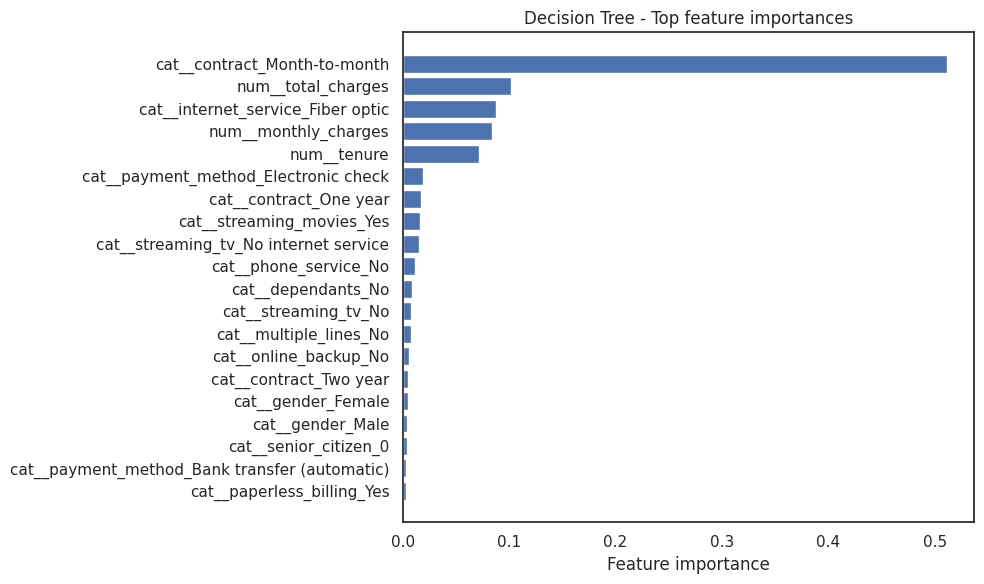

Saved DT feature importances to: /content/drive/MyDrive/ML_Backup/evaluation_outputs/dt_feature_importances.png


In [267]:
# feature importances (for saved model)
if dt_pipeline is not None:
    try:
        model_step = dt_pipeline.named_steps.get('model', dt_pipeline)
        importances = model_step.feature_importances_
        if 'X_encoded_df' in globals():
            feature_names = X_encoded_df.columns.tolist()
        elif 'preprocessor' in globals():
            try:
                feature_names = preprocessor.get_feature_names_out()
            except Exception:
                feature_names = [f"f{i}" for i in range(importances.shape[0])]
        else:
            feature_names = [f"f{i}" for i in range(importances.shape[0])]
        idx = np.argsort(importances)[::-1]
        topk = min(20, len(importances))
        plt.figure(figsize=(10,6))
        plt.barh(np.array(feature_names)[idx][:topk][::-1], importances[idx][:topk][::-1])
        plt.xlabel("Feature importance")
        plt.title("Decision Tree - Top feature importances")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "dt_feature_importances.png"))
        plt.show()
        print("Saved DT feature importances to:", os.path.join(OUT_DIR, "dt_feature_importances.png"))
    except Exception as e:
        print("Could not extract DT feature importances:", str(e))
else:
    print("DT pipeline missing; skipping feature importances.")


##Neural Network Evaluation

In [268]:
#Neural Network evaluation
if nn_model is not None:
    y_proba_nn = nn_model.predict(X_test_nn).ravel()
    # load stored threshold if available
    nn_best_thresh = None
    if os.path.exists(NN_THRESH_PATH):
        try:
            with open(NN_THRESH_PATH, "r") as f:
                d = json.load(f)
                nn_best_thresh = float(d.get("best_threshold", d.get("best_thresh", 0.5)))
        except Exception:
            nn_best_thresh = None
    if nn_best_thresh is None:
        nn_best_thresh = best_threshold_by_f1(y_test, y_proba_nn)
    y_pred_nn = (y_proba_nn >= nn_best_thresh).astype(int)
    results['NN'] = {
        'y_proba': y_proba_nn,
        'y_pred': y_pred_nn,
        'best_thresh': nn_best_thresh,
        'roc_auc': roc_auc_score(y_test, y_proba_nn),
        'pr_auc': average_precision_score(y_test, y_proba_nn),
        'f1': f1_score(y_test, y_pred_nn),
        'precision': precision_score(y_test, y_pred_nn, zero_division=0),
        'recall': recall_score(y_test, y_pred_nn),
        'accuracy': accuracy_score(y_test, y_pred_nn),
        'confusion_matrix': confusion_matrix(y_test, y_pred_nn),
        'report': classification_report(y_test, y_pred_nn, digits=4)
    }
    print("Neural Network: threshold used =", results['NN']['best_thresh'], "F1 =", results['NN']['f1'])
else:
    print("Skipping NN evaluation (model missing).")


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Neural Network: threshold used = 0.7068102955818176 F1 = 0.6214549938347719


##Comparison

###Metric summary

In [269]:
# Summary metrics table (for saved models)
rows = []
for name, res in results.items():
    rows.append({
        "model": name,
        "roc_auc": round(res['roc_auc'], 4),
        "pr_auc": round(res['pr_auc'], 4),
        "f1": round(res['f1'], 4),
        "precision": round(res['precision'], 4),
        "recall": round(res['recall'], 4),
        "accuracy": round(res['accuracy'], 4),
        "best_thresh": round(res['best_thresh'], 4)
    })
summary_df = pd.DataFrame(rows).set_index("model")
print("\nSummary metrics:\n", summary_df)
summary_df.to_csv(os.path.join(OUT_DIR, "model_metrics_summary.csv"))




Summary metrics:
        roc_auc  pr_auc      f1  precision  recall  accuracy  best_thresh
model                                                                   
DT      0.8289  0.6109  0.6333     0.5608  0.7273    0.7761       0.5729
NN      0.8254  0.6000  0.6215     0.5767  0.6738    0.7818       0.7068


###ROC curve plot

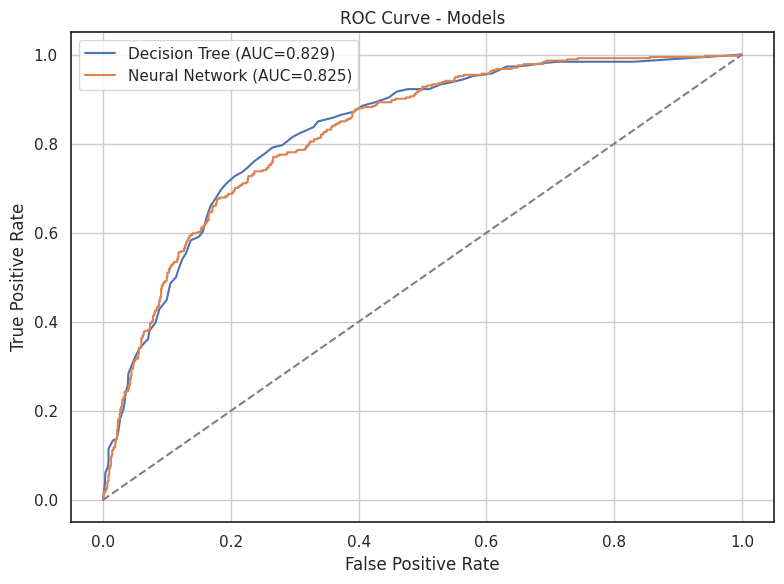

Saved ROC plot to: /content/drive/MyDrive/ML_Backup/evaluation_outputs/roc_curves.png


In [270]:
plt.figure(figsize=(8,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{standard_names.get(name, name)} (AUC={res['roc_auc']:.3f})")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curves.png"))
plt.show()
print("Saved ROC plot to:", os.path.join(OUT_DIR, "roc_curves.png"))


###Precision - recall curve plot

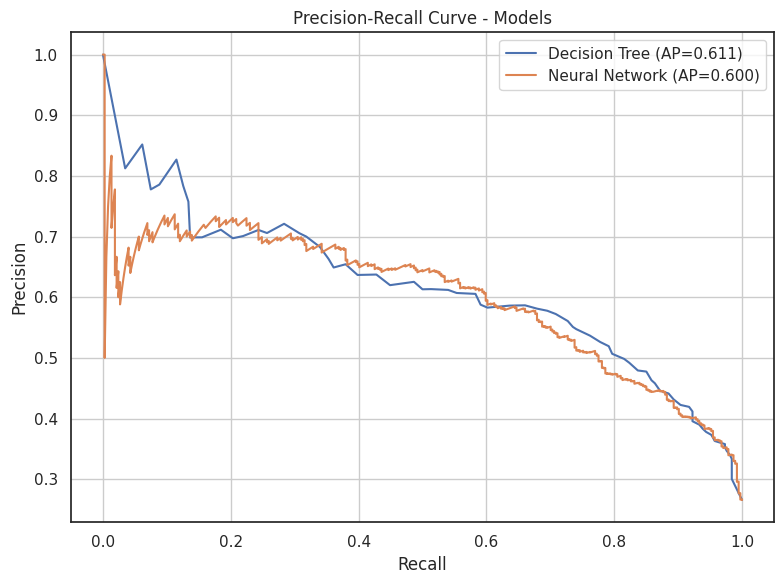

Saved PR plot to: /content/drive/MyDrive/ML_Backup/evaluation_outputs/pr_curves.png


In [271]:
#Precision-Recall curves plot
plt.figure(figsize=(8,6))
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ap = average_precision_score(y_test, res['y_proba'])
    plt.plot(rec, prec, label=f"{standard_names.get(name, name)} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pr_curves.png"))
plt.show()
print("Saved PR plot to:", os.path.join(OUT_DIR, "pr_curves.png"))


###Confusion Matrix (side-by-side)

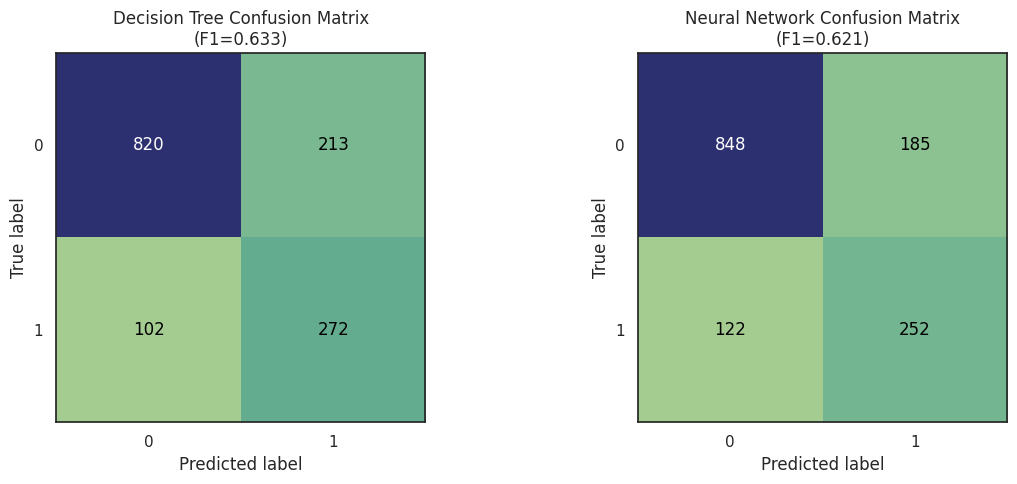

Saved confusion matrices to: /content/drive/MyDrive/ML_Backup/evaluation_outputs/confusion_matrices.png


In [272]:
#Confusion matrices (side-by-side)
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(6*n,5))
if n == 1:
    axes = [axes]
for ax, (name, res) in zip(axes, results.items()):
    cm = res['confusion_matrix']
    im = ax.imshow(cm, interpolation='nearest',cmap='crest')
    ax.set_title(f"{standard_names.get(name, name)} Confusion Matrix\n(F1={res['f1']:.3f})")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrices.png"))
plt.show()
print("Saved confusion matrices to:", os.path.join(OUT_DIR, "confusion_matrices.png"))


###Grouped bar chart (Metrics)

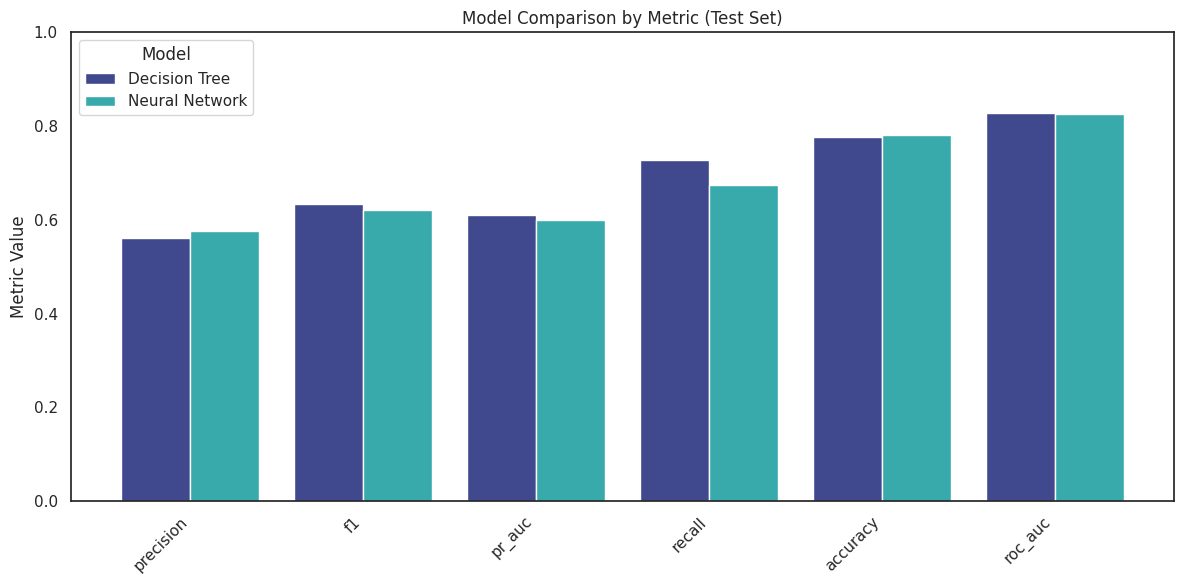

Saved grouped bar chart to: /content/drive/MyDrive/ML_Backup/evaluation_outputs/model_metrics_comparison_by_metric.png


In [273]:
metrics_to_plot = ['precision','f1','pr_auc','recall','accuracy','roc_auc']
model_names = list(results.keys())

vals = np.array([
    [results[m][metric] for metric in metrics_to_plot]
    for m in model_names
])

n_models = vals.shape[0]
n_metrics = vals.shape[1]

x = np.arange(n_metrics)
total_width = 0.8
width = total_width / n_models


palette = sns.color_palette("mako", n_colors=n_models)
fig, ax = plt.subplots(figsize=(12,6))
for i, model in enumerate(model_names):
    ax.bar(x + (i - (n_models-1)/2) * width, vals[i], width=width, label=standard_names.get(model, model),
           color=palette[i])

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel("Metric Value")
ax.set_title("Model Comparison by Metric (Test Set)")
ax.legend(title="Model")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "model_metrics_comparison_by_metric.png"))
plt.show()
print("Saved grouped bar chart to:", os.path.join(OUT_DIR, "model_metrics_comparison_by_metric.png"))
